<a href="https://colab.research.google.com/github/SHREYASHSHAURYA/ML-6th-Sem-Lab/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load the Adult Income Dataset



In [ ]:
import pandas as pd

# Define the column names as the dataset does not have a header
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Load the dataset directly from the UCI archive
df = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data',
    names=column_names,
    na_values='?', # Treat '?' as NaN values
    skipinitialspace=True # Skip spaces after commas
)

# Display the first few rows and general info
print("Dataset Head:")
display(df.head())

print("\nDataset Info:")
df.info()

Dataset Head:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


### Data Preprocessing

Before applying PCA, preprocess the data. This involves:
1.  **Handling Missing Values**
2.  **Encoding Categorical Features**
3.  **Scaling Numerical Features**

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Drop rows with any missing values identified by '?'
df_processed = df.dropna().copy()

# Separate features (X) from the target (income) if we were doing a supervised task,
# but for PCA we typically use all features (except identifier or target if explicitly excluded).
# For now, let's include all features except 'income' to see feature reduction.
X = df_processed.drop('income', axis=1)

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

# Create a preprocessing pipeline for numerical and categorical features
# Use ColumnTransformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Apply preprocessing
X_preprocessed = preprocessor.fit_transform(X)

# Get the feature names after one-hot encoding (for understanding components later)
# This part can be tricky with ColumnTransformer if not careful with versions/settings
# A simpler way to get names for OneHotEncoder:
# ohe_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
# all_feature_names = numerical_features + list(ohe_features)

print(f"\nShape of preprocessed data: {X_preprocessed.shape}")

Numerical features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Shape of preprocessed data: (30162, 104)


### Apply Principal Component Analysis (PCA)



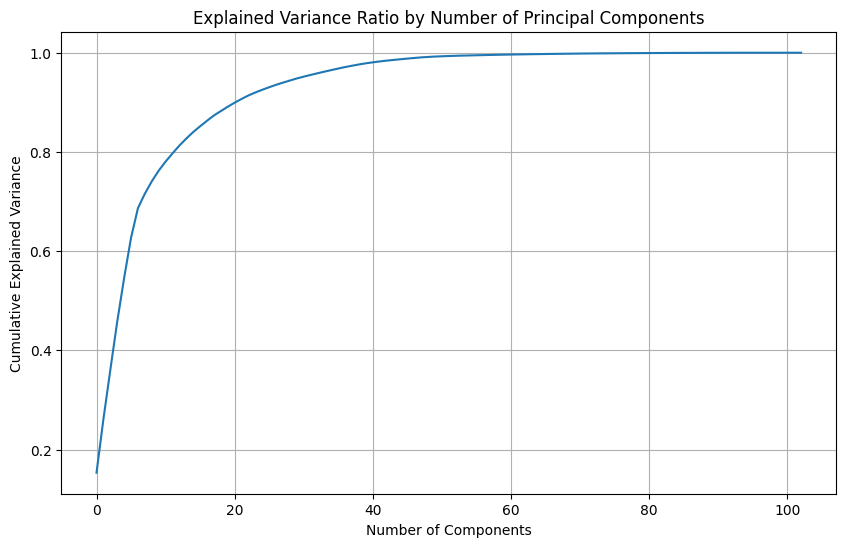

Individual Explained Variance Ratio:
Principal Component 1: 0.1533
Principal Component 2: 0.1079
Principal Component 3: 0.0993
Principal Component 4: 0.0974
Principal Component 5: 0.0879
Principal Component 6: 0.0811
Principal Component 7: 0.0598
Principal Component 8: 0.0290
Principal Component 9: 0.0248
Principal Component 10: 0.0216

Number of components to explain 95% of variance: 31


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize PCA without specifying n_components to determine optimal number
pca = PCA()
pca.fit(X_preprocessed)

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance Ratio by Number of Principal Components')
plt.grid(True)
plt.show()

# Display individual explained variance ratio
print("Individual Explained Variance Ratio:")
for i, ratio in enumerate(pca.explained_variance_ratio_[:10]): # Display first 10
    print(f"Principal Component {i+1}: {ratio:.4f}")

# Determine number of components for, e.g., 95% variance
num_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print(f"\nNumber of components to explain 95% of variance: {num_components}")

### Transform Data with Selected Components (e.g., 2 components for visualization)


Transformed data (first 5 rows with 2 principal components):


,principal_component_1,principal_component_2,income
0,0.438295,1.143784,<=50K
1,0.514880,0.008404,<=50K
2,-0.497461,-0.395871,<=50K
3,0.174199,-1.741689,<=50K
4,-0.253441,1.520006,<=50K


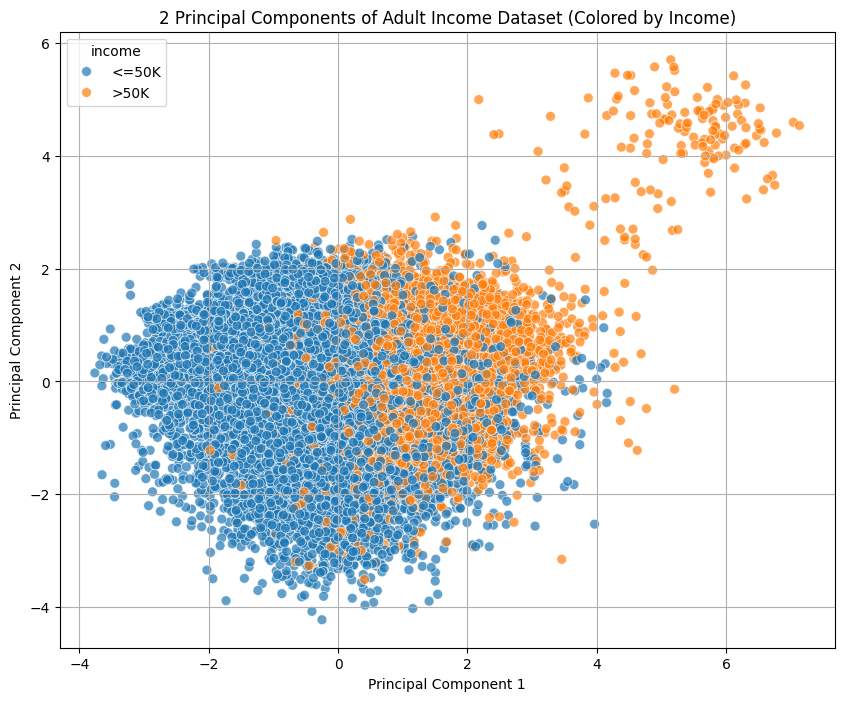

In [ ]:
pca_2_components = PCA(n_components=2)
X_pca = pca_2_components.fit_transform(X_preprocessed)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['principal_component_1', 'principal_component_2'])

# Add the original 'income' column back for visualization context
# Make sure the indices align after dropping NaNs
pca_df['income'] = df_processed['income'].reset_index(drop=True)

print("Transformed data (first 5 rows with 2 principal components):")
display(pca_df.head())

# Visualize the 2 principal components
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    hue='income', # Color by income to see separation
    data=pca_df,
    alpha=0.7,
    s=50
)
plt.title('2 Principal Components of Adult Income Dataset (Colored by Income)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()